In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/housevotes/house-votes-84.data


In [2]:
import pandas as pd 

In [3]:
file=pd.read_csv("/kaggle/input/housevotes/house-votes-84.data", sep=",")

In [4]:
file.head()

,republican,n,y,n.1,y.1,y.2,y.3,n.2,n.3,n.4,y.4,?,y.5,y.6,y.7,n.5,y.8
0,republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,?
1,democrat,?,y,y,?,y,y,n,n,n,n,y,n,y,y,n,n
2,democrat,n,y,y,n,?,y,n,n,n,n,y,n,y,n,n,y
3,democrat,y,y,y,n,y,y,n,n,n,n,y,?,y,y,y,y
4,democrat,n,y,y,n,y,y,n,n,n,n,n,n,y,y,y,y


In [5]:
file.columns=['predict','A','B','C','D','E','F','G','H','I','J','K','L','M','N','o','P']

In [6]:
file.head()

,predict,A,B,C,D,E,F,G,H,I,J,K,L,M,N,o,P
0,republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,?
1,democrat,?,y,y,?,y,y,n,n,n,n,y,n,y,y,n,n
2,democrat,n,y,y,n,?,y,n,n,n,n,y,n,y,n,n,y
3,democrat,y,y,y,n,y,y,n,n,n,n,y,?,y,y,y,y
4,democrat,n,y,y,n,y,y,n,n,n,n,n,n,y,y,y,y


In [7]:
file.isnull().sum()

predict    0
A          0
B          0
C          0
D          0
E          0
F          0
G          0
H          0
I          0
J          0
K          0
L          0
M          0
N          0
o          0
P          0
dtype: int64

In [8]:
def count_miss_by_col(d):
 c=0
 for i in d:
  if i=='?':
   c+=1
 return c

In [9]:
print(count_miss_by_col(file['A']))
print(count_miss_by_col(file['B']))
print(count_miss_by_col(file['C']))
print(count_miss_by_col(file['D']))
print(count_miss_by_col(file['E']))
print(count_miss_by_col(file['F']))
print(count_miss_by_col(file['G']))
print(count_miss_by_col(file['H']))
print(count_miss_by_col(file['I']))
print(count_miss_by_col(file['J']))
print(count_miss_by_col(file['K']))
print(count_miss_by_col(file['L']))
print(count_miss_by_col(file['M']))
print(count_miss_by_col(file['N']))
print(count_miss_by_col(file['o']))
print(count_miss_by_col(file['P']))

12
48
11
11
15
11
14
15
22
7
20
31
25
17
28
104


In [10]:
file.describe()

,predict,A,B,C,D,E,F,G,H,I,J,K,L,M,N,o,P
count,434,434,434,434,434,434,434,434,434,434,434,434,434,434,434,434,434
unique,2,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
top,democrat,n,y,y,n,y,y,y,y,y,y,n,n,y,y,n,y
freq,267,235,194,253,247,211,271,239,242,207,215,264,233,208,247,232,268


In [11]:
def clean_data(df):
  x=df.mode()
  for i in range(0,len(df)):
   if df[i]=='?':
       df[i]=x[0]
  return df 


In [12]:
print(clean_data(file['A']))
print(clean_data(file['B']))
print(clean_data(file['C']))
print(clean_data(file['D']))
print(clean_data(file['E']))
print(clean_data(file['F']))
print(clean_data(file['G']))
print(clean_data(file['H']))
print(clean_data(file['I']))
print(clean_data(file['J']))
print(clean_data(file['K']))
print(clean_data(file['L']))
print(clean_data(file['M']))
print(clean_data(file['N']))
print(clean_data(file['o']))
print(clean_data(file['P']))

0      n
1      n
2      n
3      y
4      n
      ..
429    n
430    n
431    n
432    n
433    n
Name: A, Length: 434, dtype: object
0      y
1      y
2      y
3      y
4      y
      ..
429    n
430    n
431    y
432    n
433    y
Name: B, Length: 434, dtype: object
0      n
1      y
2      y
3      y
4      y
      ..
429    y
430    y
431    n
432    n
433    n
Name: C, Length: 434, dtype: object
0      y
1      n
2      n
3      n
4      n
      ..
429    y
430    n
431    y
432    y
433    y
Name: D, Length: 434, dtype: object
0      y
1      y
2      y
3      y
4      y
      ..
429    y
430    n
431    y
432    y
433    y
Name: E, Length: 434, dtype: object
0      y
1      y
2      y
3      y
4      y
      ..
429    y
430    n
431    y
432    y
433    y
Name: F, Length: 434, dtype: object
0      n
1      n
2      n
3      n
4      n
      ..
429    n
430    y
431    n
432    y
433    n
Name: G, Length: 434, dtype: object
0      n
1      n
2      n
3      n
4      n
      ..
4

In [13]:
# after cleaning wrong values 
print(file.head(10))

      predict  A  B  C  D  E  F  G  H  I  J  K  L  M  N  o  P
0  republican  n  y  n  y  y  y  n  n  n  n  n  y  y  y  n  y
1    democrat  n  y  y  n  y  y  n  n  n  n  y  n  y  y  n  n
2    democrat  n  y  y  n  y  y  n  n  n  n  y  n  y  n  n  y
3    democrat  y  y  y  n  y  y  n  n  n  n  y  n  y  y  y  y
4    democrat  n  y  y  n  y  y  n  n  n  n  n  n  y  y  y  y
5    democrat  n  y  n  y  y  y  n  n  n  n  n  n  y  y  y  y
6  republican  n  y  n  y  y  y  n  n  n  n  n  n  y  y  n  y
7  republican  n  y  n  y  y  y  n  n  n  n  n  y  y  y  n  y
8    democrat  y  y  y  n  n  n  y  y  y  n  n  n  n  n  n  y
9  republican  n  y  n  y  y  n  n  n  n  n  n  n  y  y  n  n


In [14]:
#get all categorical columns
cat_columns = file.select_dtypes(['object']).columns

#convert all categorical columns to numeric
file[cat_columns] = file[cat_columns].apply(lambda x: pd.factorize(x)[0])

print(file.head())

   predict  A  B  C  D  E  F  G  H  I  J  K  L  M  N  o  P
0        0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
1        1  0  0  1  1  0  0  0  0  0  0  1  1  0  0  0  1
2        1  0  0  1  1  0  0  0  0  0  0  1  1  0  1  0  0
3        1  1  0  1  1  0  0  0  0  0  0  1  1  0  0  1  0
4        1  0  0  1  1  0  0  0  0  0  0  0  1  0  0  1  0


In [15]:
# dependant variables
x= file.iloc[:, 1:-1].values  
# independant variables
y= file.iloc[:, 0].values
print(x)
print(y)   

[[0 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 [0 0 1 ... 0 1 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[0 1 1 1 1 1 0 0 1 0 0 1 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1 0 1 0 1 1 0 1 0 0 0
 0 1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 1 0 0 0 0 0 1 0 1 1 1 0 0 0 1 1 1 0 1 0 1
 1 1 1 1 0 1 1 0 0 0 1 0 0 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 0 1 1 1 0
 1 0 1 1 1 0 1 0 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1 0
 1 0 1 1 1 0 0 0 1 0 1 1 1 1 0 1 1 0 0 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1
 1 1 0 1 0 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 0 0 1 1 1 0 1 1 0 1 1 0 1 1 1 1 1
 0 0 0 1 1 0 0 0 0 1 0 1 0 1 1 1 0 0 1 0 1 1 1 1 0 0 1 0 0 1 0 1 1 0 0 1 1
 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 0 0 0 0 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0
 1 1 1 0 1 0 0 0 0 0 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 1 1
 1 0 1 1 1 0 0 1 1 0 1 0 0 0 1 0 1 0 1 0 1 0 0 0 1 0 1 1 1 0 0 1 1 1 1 0 1
 1 1 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 1 1
 1 0 0 1 0 0 1 1 0 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 0 0 0]

In [16]:
from numpy.lib.function_base import append
from sklearn.model_selection import train_test_split  
# we will change test,train size,random state according to best accuracy 
x_train_list=[]
x_test_list=[]
y_train_list=[]
y_test_list=[]
for i in range (0,10):
 x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 1/((i+2)), random_state=10*i+i)
 x_train_list.append(x_train)  
 x_test_list.append(x_test)
 y_train_list.append(y_train)
 y_test_list.append(y_test)  
                                          
print(x_train_list[0])
print("############################")
print(x_test_list[0])
print("##############################33")
print(y_train_list[0])
print("#####################################")
print(y_test_list[0])

[[1 0 1 ... 1 1 1]
 [0 1 1 ... 1 1 1]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 1 ... 1 1 1]
 [1 0 1 ... 1 0 0]
 [0 1 0 ... 0 0 0]]
############################
[[1 0 1 ... 1 1 1]
 [1 0 1 ... 1 1 1]
 [0 1 0 ... 0 0 0]
 ...
 [1 0 1 ... 1 1 0]
 [0 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 1]]
##############################33
[1 1 0 1 1 1 1 0 1 1 1 1 0 0 1 1 1 0 1 0 0 1 0 0 0 0 1 1 1 0 1 0 0 1 0 1 1
 0 1 1 1 1 1 0 1 0 1 1 0 1 0 0 0 0 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 0 0
 0 1 1 1 1 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 1 1 0 1 0 0 1 1 0 1 0 1 0 1 1 0 1
 1 0 0 1 1 0 1 0 1 1 1 1 0 0 1 1 1 0 1 1 0 1 0 1 0 1 1 0 1 0 0 0 1 0 1 0 0
 1 0 1 1 1 1 0 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 1 0 1 1
 1 1 0 0 0 1 1 0 1 1 1 1 1 1 0 1 0 0 1 1 1 0 1 0 1 1 1 0 1 1 1 1]
#####################################
[1 1 0 1 0 1 1 0 1 1 0 1 0 1 1 0 1 1 1 0 1 0 0 1 1 1 0 1 1 0 1 0 1 1 0 0 0
 0 0 1 1 0 1 0 1 1 1 0 1 0 1 1 1 0 0 0 0 1 1 1 0 0 1 1 1 0 1 0 0 1 0 1 1 1
 1 0 0 1 0 1 0 1 1 1 1 1 0 0 1 1 1 1 1 0 1 0 0 1 1 1 1 1 0 0 0 0 0 1 

In [17]:
#Fitting Decision Tree classifier to the training set  
from sklearn.tree import DecisionTreeClassifier  
# classfifier list to carry fitness 
classefier_list=[]
listl=[]
for i in range(0,10):
    classifier= DecisionTreeClassifier(criterion='entropy', random_state=i)  
    classefier_list.append(classifier.fit(x_train_list[i], y_train_list[i]))
    print(classefier_list[i].tree_.node_count)
    listl.append(classefier_list[i].tree_.node_count)
    

31
45
45
37
57
49
57
59
57
53


In [18]:
#Predicting the test set result 
y_pred_list=[]
for i in range(0,10):
    y_pred=classefier_list[i].predict(x_test_list[i])
    y_pred_list.append(y_pred)

In [19]:
#Creating the Confusion matrix  
from sklearn.metrics import confusion_matrix
# confusion matrix to test the accuracy 
conf_matrix=[]
for i in range(0,10):
    cm= confusion_matrix(y_test_list[i], y_pred_list[i]) 
    print(cm)
  

[[ 78   7]
 [  7 125]]
[[57  1]
 [ 7 80]]
[[29  2]
 [ 4 74]]
[[33  0]
 [ 6 48]]
[[31  7]
 [ 2 33]]
[[20  2]
 [ 3 37]]
[[29  0]
 [ 1 25]]
[[24  0]
 [ 1 24]]
[[19  0]
 [ 3 22]]
[[18  0]
 [ 4 18]]


In [20]:
from sklearn import metrics
# Model Accuracy, how often is the classifier correct?
# make accuracy matrix to get maximum acc and index of it
accuracy_matrix=[]
max_acc=0
for i in range(0,10):
             print("Accuracy :",metrics.accuracy_score(y_test_list[i], y_pred_list[i]))
             accuracy_matrix.append(metrics.accuracy_score(y_test_list[i], y_pred_list[i]))
             
                
#max_acc=max(accuracy_matrix)            
#print("the maximum score is ",max_acc)
max_val_idx = 0
max_val = accuracy_matrix[0]
for i in range(0,10):
     if accuracy_matrix[i] > max_val:
                max_val =accuracy_matrix[i]
                max_val_idx = i
# display the max value
print("the maximum in the accuracy ",max_val)
# display its index
print("the index of max_val is ", max_val_idx)
test_size_final= 1/((max_val_idx+2))
print("the size that max that accuracy is ",test_size_final)

Accuracy : 0.9354838709677419
Accuracy : 0.9448275862068966
Accuracy : 0.944954128440367
Accuracy : 0.9310344827586207
Accuracy : 0.8767123287671232
Accuracy : 0.9193548387096774
Accuracy : 0.9818181818181818
Accuracy : 0.9795918367346939
Accuracy : 0.9318181818181818
Accuracy : 0.9
the maximum in the accuracy  0.9818181818181818
the index of max_val is  6
the size that max that accuracy is  0.125


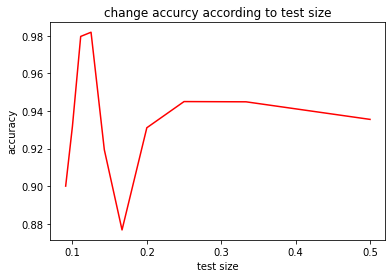

In [21]:
from sklearn import metrics
import matplotlib.pyplot as plt
# plotting 
l1=[]
l2=[]
l3=[]
for i in range(0,10):
    test_size= 1/((i+2))
    train_size=1-(1/((i+2)))
    l1.append(test_size)
    acc=metrics.accuracy_score(y_test_list[i], y_pred_list[i])
    l2.append(acc)
    l3.append(train_size)
plt.plot(l1,l2,'r')
plt.title("change accurcy according to test size")
plt.xlabel("test size")
plt.ylabel("accuracy")
plt.show()
    

[31, 45, 45, 37, 57, 49, 57, 59, 57, 53]
[0.5, 0.3333333333333333, 0.25, 0.2, 0.16666666666666666, 0.14285714285714285, 0.125, 0.1111111111111111, 0.1, 0.09090909090909091]


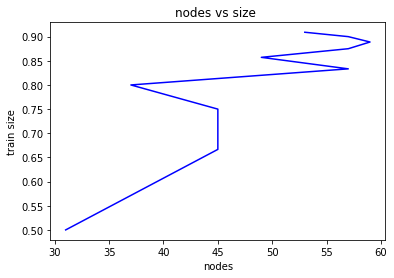

In [22]:
print(listl)
print(l1)
plt.plot(listl,l3,'b')
plt.xlabel("nodes")
plt.ylabel("train size")
plt.title("nodes vs size ")
plt.show()